# Chapter 13: Scene Planes and Homographies

Source orientation: printed pages 325-343; PDF pages 343-361. This notebook uses that span for section names and mathematical concepts only: plane-induced homographies, homographies given a plane and conversely a plane from a homography, homographies compatible with a fundamental matrix, computing a homography from `F` and image correspondences, computing `F` from a plane homography through parallax, and the infinite homography.


## Chapter Goal

A world plane is the simplest surface that lets two-view geometry stop being a point-by-point triangulation problem and become a direct image-to-image transfer. The goal of this chapter is to make that transfer inspectable: points on the chosen plane should move exactly by one homography, points away from the plane should miss that prediction along their epipolar lines, and the plane at infinity should isolate the rotation-only part of the camera motion.


## Library Routing

This chapter uses NumPy and the course camera helpers for the plane-induced homography formula because the learner needs to inspect the normal, depth, rotation, and translation terms. OpenCV is used for `perspectiveTransform` and raster warps, matching the image-transfer operation that homographies perform in practice. SymPy is used only for the infinite-depth limit where the translation term vanishes. Matplotlib handles the static transfer fields, parallax vectors, factorization panel, and infinite-homography comparison.

## Translation Guide

- A plane in camera-1 coordinates is written as `n.T @ X + d = 0`; the example plane is in front of the first camera, so `d` is negative.
- A calibrated second camera is `P2 = K [R | t]`, where `X2 = R X1 + t`. For the finite plane, the induced homography is `H_plane = K (R - t n.T / d) K^-1`.
- The infinite homography is `H_inf = K R K^-1`. It is what remains when the plane depth tends to infinity or when translation should not affect the transfer.
- The fundamental matrix for the calibrated pair is `F = K^-T [t]_x R K^-1`. If `x2` is a real image point and `H_plane x1` is the plane-transfer prediction, their difference is the plane-induced parallax. In the second image, that parallax line is the epipolar line.
- Homogeneous equalities are always compared after scale normalization or through incidence residuals such as `x2.T @ F @ x1`.


## Visual Storyboard

| Visual | Artifact | What to inspect | Check |
| --- | --- | --- | --- |
| Plane transfer field | `figures/plane-induced-transfer-field.png` | A grid on the reference plane moves from view 1 to view 2 by one image homography. | OpenCV `perspectiveTransform` agrees with direct 3D projection for planar points. |
| Off-plane parallax vectors | `figures/off-plane-parallax-vectors.png` | Points away from the plane miss the plane transfer, and the miss lies along the epipolar line. | The signed point-line epipolar residual is near zero while vector lengths are nonzero. |
| Plane-to-H formula diagnostic | `figures/plane-homography-factorization.png` | Rotation, translation, plane normal, and inverse depth combine as `R - t n.T / d`. | Numeric formula matches projected correspondences and a DLT homography. |
| Infinite homography rotation component | `figures/infinite-homography-rotation.png` plus `checks/plane-homography-invariants.json` | Translation-dependent finite-plane warp versus rotation-only infinite warp. | Pure rotation leaves parallax near zero, and the symbolic limit removes the translation term. |


In [1]:
from pathlib import Path
import sys

BOOK_ROOT = Path.cwd()
for candidate in [BOOK_ROOT, *BOOK_ROOT.parents]:
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
else:
    raise RuntimeError("Could not find the MVG book root")

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

TOPIC = "chapter-13"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / TOPIC
(ARTIFACT_ROOT / "figures").mkdir(parents=True, exist_ok=True)
(ARTIFACT_ROOT / "checks").mkdir(parents=True, exist_ok=True)


In [2]:
import json
import math

import cv2
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

from utils.artifacts import assert_artifacts, display_artifact, save_json, save_matplotlib
from utils.cameras import make_calibration
from utils.epipolar import sampson_errors
from utils.projective import dehomogenize, dlt_homography, homogenize

plt.rcParams.update({"figure.dpi": 140, "font.size": 10})


def skew(v):
    x, y, z = np.asarray(v, dtype=float).reshape(3)
    return np.array([[0.0, -z, y], [z, 0.0, -x], [-y, x, 0.0]])


def rotation_y(theta):
    c, s = math.cos(theta), math.sin(theta)
    return np.array([[c, 0.0, s], [0.0, 1.0, 0.0], [-s, 0.0, c]])


def rotation_x(theta):
    c, s = math.cos(theta), math.sin(theta)
    return np.array([[1.0, 0.0, 0.0], [0.0, c, -s], [0.0, s, c]])


def project(K, R, t, points):
    pts = np.asarray(points, dtype=float)
    cam = (R @ pts.T).T + np.asarray(t, dtype=float).reshape(1, 3)
    img_h = (K @ cam.T).T
    return dehomogenize(img_h)


def apply_H(H, points):
    pts = np.asarray(points, dtype=np.float64).reshape(-1, 1, 2)
    return cv2.perspectiveTransform(pts, H.astype(np.float64)).reshape(-1, 2)


def point_line_distance(lines, points_h):
    numer = np.abs(np.sum(lines * points_h, axis=1))
    denom = np.linalg.norm(lines[:, :2], axis=1)
    return numer / np.maximum(denom, 1e-12)


def normalize_matrix(M):
    M = np.asarray(M, dtype=float)
    return M / M[2, 2]


def synthetic_texture(width=520, height=360):
    image = np.full((height, width, 3), 246, dtype=np.uint8)
    for x in range(40, width, 80):
        cv2.line(image, (x, 25), (x, height - 25), (190, 190, 190), 1, cv2.LINE_AA)
    for y in range(40, height, 70):
        cv2.line(image, (30, y), (width - 30, y), (200, 200, 200), 1, cv2.LINE_AA)
    cv2.rectangle(image, (65, 65), (215, 150), (70, 115, 190), -1, cv2.LINE_AA)
    cv2.circle(image, (365, 220), 48, (185, 90, 80), -1, cv2.LINE_AA)
    cv2.putText(image, "plane", (78, 120), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 255, 255), 2, cv2.LINE_AA)
    cv2.putText(image, "H", (345, 232), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255, 255, 255), 2, cv2.LINE_AA)
    return image

artifact_paths = []


## Synthetic Two-View Plane Lab

The lab uses a deliberately small calibrated pair so every matrix can be read directly. Camera 1 is the reference frame. Camera 2 rotates slightly and translates to the side. The chosen scene plane is `z = 4`, so all planar grid points have the same physical depth in camera-1 coordinates. Off-plane samples are made by changing only depth; they keep the same `x,y` footprint so the parallax relative to the plane is easy to see.


In [3]:
K = make_calibration(820.0, 790.0, 320.0, 240.0)
R = rotation_y(math.radians(8.0)) @ rotation_x(math.radians(-3.5))
t = np.array([0.72, 0.06, 0.18])
n = np.array([0.0, 0.0, 1.0])
d = -4.0
plane_z = -d

H_plane = normalize_matrix(K @ (R - np.outer(t, n) / d) @ np.linalg.inv(K))
H_inf = normalize_matrix(K @ R @ np.linalg.inv(K))
F = np.linalg.inv(K).T @ skew(t) @ R @ np.linalg.inv(K)
F = F / np.linalg.norm(F)
e2 = K @ t
e2 = e2 / e2[2]

xs = np.linspace(-1.25, 1.25, 7)
ys = np.linspace(-0.85, 0.85, 5)
plane_points = np.array([[x, y, plane_z] for y in ys for x in xs], dtype=float)
plane_xy = plane_points[:, :2]

x1_plane = project(K, np.eye(3), np.zeros(3), plane_points)
x2_plane = project(K, R, t, plane_points)
x2_plane_H = apply_H(H_plane, x1_plane)
plane_transfer_residuals = np.linalg.norm(x2_plane_H - x2_plane, axis=1)

z_offsets = np.array([-1.2, -0.7, 0.65, 1.05, -0.95, 0.85, 1.25, -0.55])
base_xy = np.array([[-1.05, -0.65], [-0.35, -0.55], [0.45, -0.48], [1.05, -0.2], [-0.8, 0.35], [-0.1, 0.55], [0.65, 0.52], [1.15, 0.65]])
off_points = np.column_stack([base_xy, plane_z + z_offsets])
x1_off = project(K, np.eye(3), np.zeros(3), off_points)
x2_off = project(K, R, t, off_points)
x2_off_by_plane = apply_H(H_plane, x1_off)
parallax_vectors = x2_off - x2_off_by_plane
parallax_lengths = np.linalg.norm(parallax_vectors, axis=1)

x1_off_h = homogenize(x1_off)
x2_off_h = homogenize(x2_off)
line_from_F = (F @ x1_off_h.T).T
epipolar_point_distances = point_line_distance(line_from_F, x2_off_h)
transfer_point_distances = point_line_distance(line_from_F, homogenize(x2_off_by_plane))
parallax_join_lines = np.cross(homogenize(x2_off), homogenize(x2_off_by_plane))
epipole_on_parallax_lines = point_line_distance(parallax_join_lines, np.repeat(e2.reshape(1, 3), len(x1_off), axis=0))

H_dlt = normalize_matrix(dlt_homography(x1_plane[:12], x2_plane[:12]))
H_formula_residual = float(np.max(np.abs(H_plane - H_dlt / H_dlt[2, 2])))


## 1. Plane Transfer Field

For points that actually lie on the selected plane, the two-view transfer is not an approximation. The arrows below start at projected grid points in the first image and end where `cv2.perspectiveTransform` sends them in the second image. The gray crosses show the second-camera projection from the original 3D points. The two marks sit on top of each other when the finite-plane formula is correct.


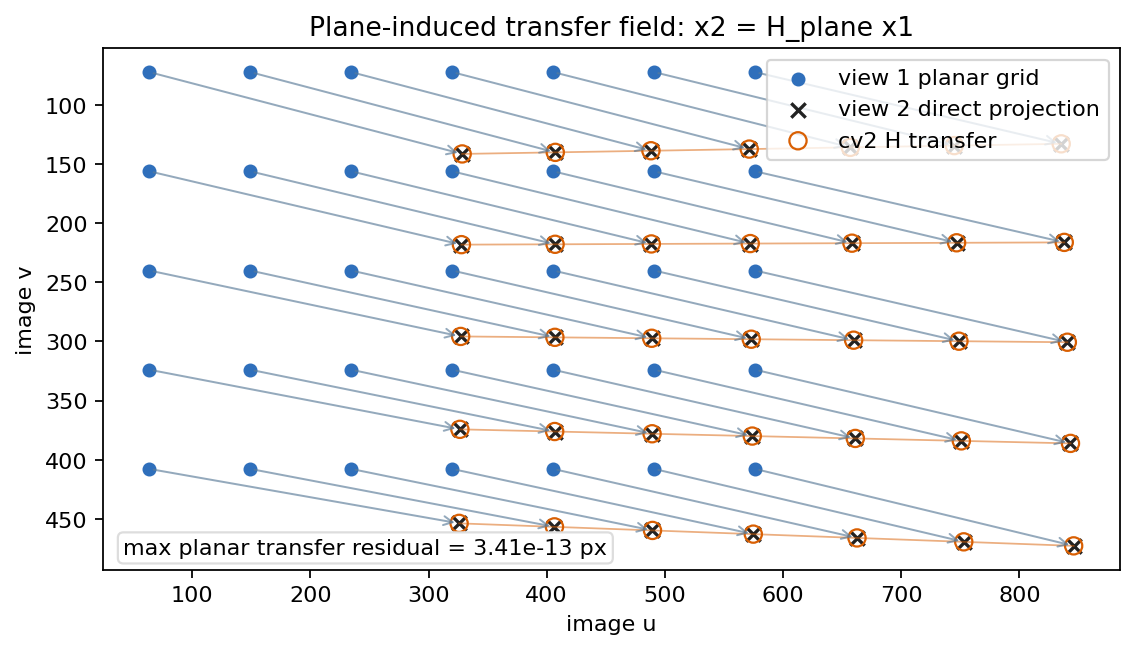

In [4]:
fig, ax = plt.subplots(figsize=(8.2, 5.7))
ax.set_title("Plane-induced transfer field: x2 = H_plane x1")
ax.scatter(x1_plane[:, 0], x1_plane[:, 1], s=28, c="#2f6fbb", label="view 1 planar grid")
ax.scatter(x2_plane[:, 0], x2_plane[:, 1], marker="x", s=42, c="#222222", label="view 2 direct projection")
ax.scatter(x2_plane_H[:, 0], x2_plane_H[:, 1], facecolors="none", edgecolors="#d95f02", s=60, label="cv2 H transfer")
for a, b in zip(x1_plane, x2_plane_H):
    ax.annotate("", xy=b, xytext=a, arrowprops={"arrowstyle": "->", "color": "#5b7c99", "lw": 0.9, "alpha": 0.65})
for y in ys:
    idx = np.where(np.isclose(plane_xy[:, 1], y))[0]
    ax.plot(x2_plane_H[idx, 0], x2_plane_H[idx, 1], color="#d95f02", lw=0.8, alpha=0.5)
ax.invert_yaxis()
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("image u")
ax.set_ylabel("image v")
ax.legend(loc="upper right", frameon=True)
ax.text(0.02, 0.03, f"max planar transfer residual = {plane_transfer_residuals.max():.2e} px", transform=ax.transAxes, bbox={"boxstyle": "round,pad=0.25", "fc": "white", "ec": "#dddddd"})
transfer_path = save_matplotlib(fig, TOPIC, "figures", "plane-induced-transfer-field.png")
plt.close(fig)
artifact_paths.append(transfer_path)
display_artifact(transfer_path)


## 2. Off-Plane Parallax Vectors

The same homography can be applied to any image point, but for off-plane scene points it predicts the image of the ray-plane intersection, not the actual 3D point. The residual vector from `H_plane x1` to the true `x2` is plane-induced parallax. Chapter 13's key geometric claim is visible here: in the second image, each parallax vector lies on the epipolar line of the original point.


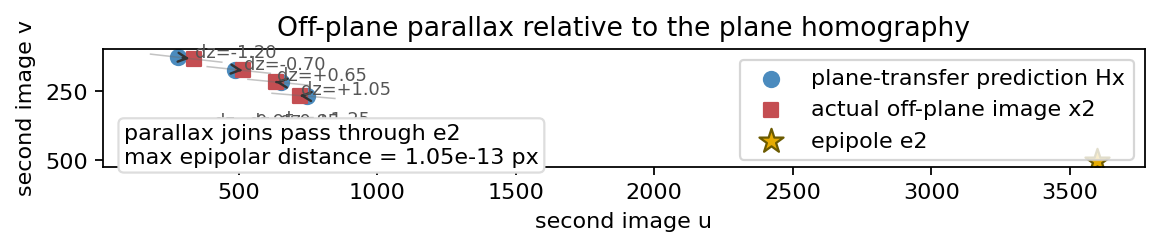

In [5]:
fig, ax = plt.subplots(figsize=(8.4, 5.8))
ax.set_title("Off-plane parallax relative to the plane homography")
ax.scatter(x2_off_by_plane[:, 0], x2_off_by_plane[:, 1], marker="o", s=46, c="#4b8bbe", label="plane-transfer prediction Hx")
ax.scatter(x2_off[:, 0], x2_off[:, 1], marker="s", s=40, c="#c44e52", label="actual off-plane image x2")
for predicted, actual, line, depth_shift in zip(x2_off_by_plane, x2_off, line_from_F, z_offsets):
    ax.annotate("", xy=actual, xytext=predicted, arrowprops={"arrowstyle": "->", "color": "#333333", "lw": 1.1})
    u_min, u_max = min(predicted[0], actual[0]) - 100, max(predicted[0], actual[0]) + 100
    us = np.linspace(u_min, u_max, 50)
    if abs(line[1]) > 1e-9:
        vs = -(line[0] * us + line[2]) / line[1]
        ax.plot(us, vs, color="#6b6b6b", lw=0.7, alpha=0.4)
    ax.text(actual[0] + 5, actual[1] - 5, f"dz={depth_shift:+.2f}", fontsize=8, color="#555555")
ax.scatter([e2[0]], [e2[1]], marker="*", s=130, c="#e6ab02", edgecolor="#6b5a00", label="epipole e2")
ax.invert_yaxis()
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("second image u")
ax.set_ylabel("second image v")
ax.legend(loc="best", frameon=True)
ax.text(0.02, 0.03, "parallax joins pass through e2\nmax epipolar distance = %.2e px" % epipolar_point_distances.max(), transform=ax.transAxes, bbox={"boxstyle": "round,pad=0.25", "fc": "white", "ec": "#dddddd"})
parallax_path = save_matplotlib(fig, TOPIC, "figures", "off-plane-parallax-vectors.png")
plt.close(fig)
artifact_paths.append(parallax_path)
display_artifact(parallax_path)


## 3. Plane-To-H Formula Diagnostic

The formula `K (R - t n.T / d) K^-1` is a compact way to say: rotate the ray, then add the translation term scaled by where that ray hits the plane. The diagnostic below separates the ingredients. The 3D panel shows the finite plane, camera-2 translation, and plane normal. The image panels compare direct projection, the closed-form homography, a DLT fit from planar correspondences, and an OpenCV raster warp of a synthetic plane texture.


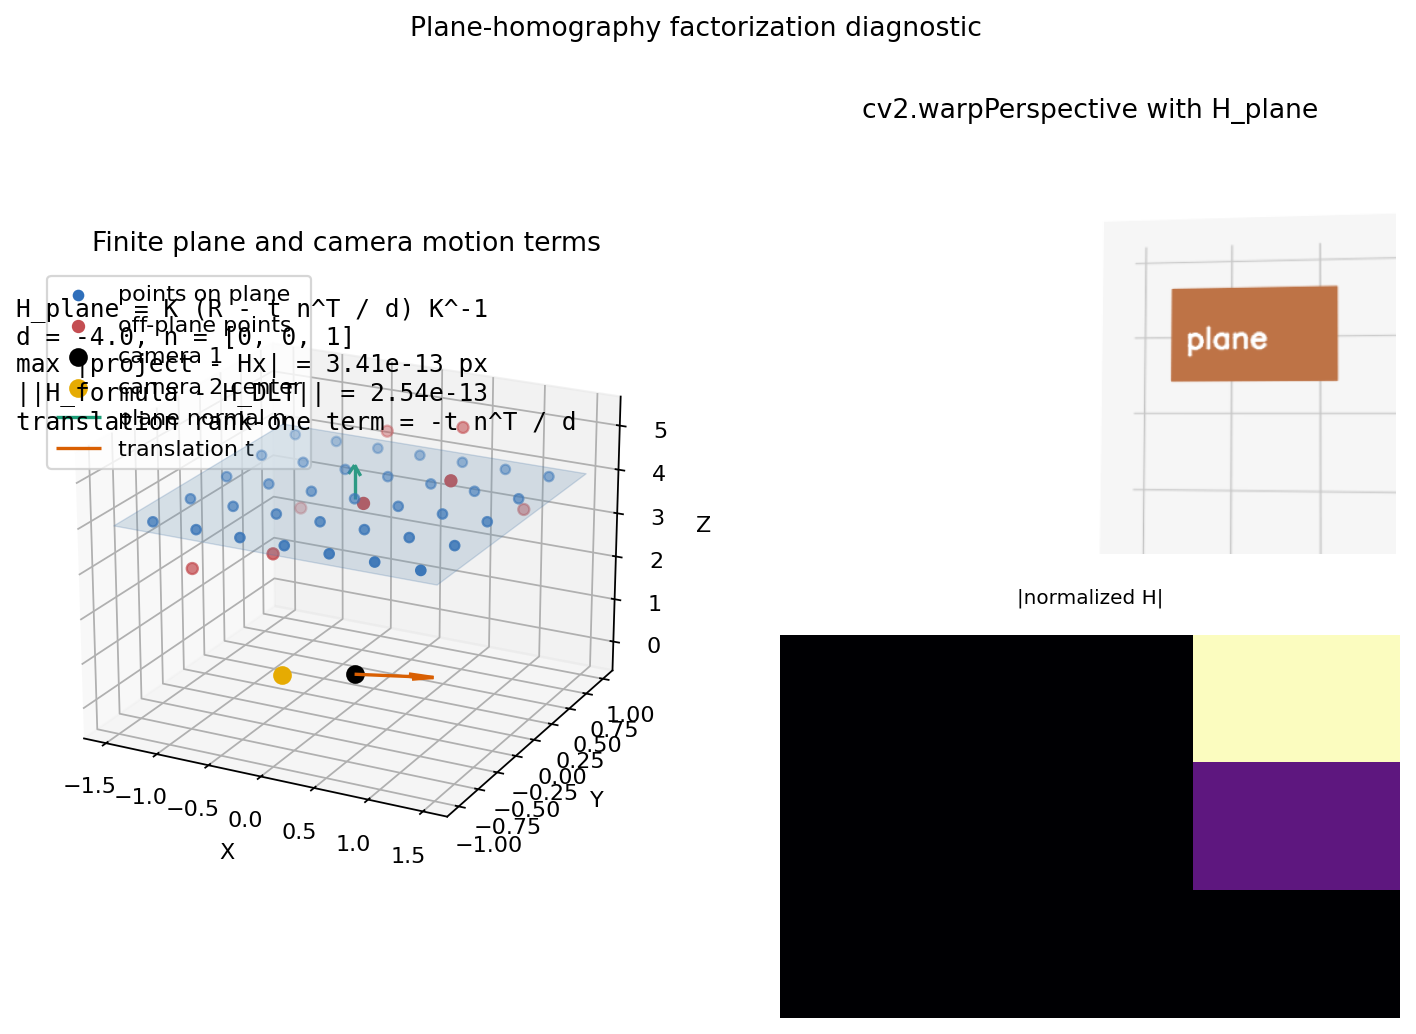

In [6]:
texture = synthetic_texture()
h, w = texture.shape[:2]
texture_corners = np.array([[0, 0], [w - 1, 0], [w - 1, h - 1], [0, h - 1]], dtype=np.float32)
texture_warp = cv2.warpPerspective(texture, H_plane.astype(np.float64), (w, h), flags=cv2.INTER_LINEAR, borderValue=(255, 255, 255))
formula_vs_projection = float(np.max(np.linalg.norm(x2_plane_H - x2_plane, axis=1)))
formula_vs_dlt = float(np.linalg.norm(normalize_matrix(H_plane) - normalize_matrix(H_dlt)))

fig = plt.figure(figsize=(11, 7.2))
gs = fig.add_gridspec(2, 2, height_ratios=[1.05, 0.95])
ax3 = fig.add_subplot(gs[:, 0], projection="3d")
xx = np.array([[-1.5, 1.5], [-1.5, 1.5]])
yy = np.array([[-1.0, -1.0], [1.0, 1.0]])
zz = np.full_like(xx, plane_z)
ax3.plot_surface(xx, yy, zz, alpha=0.24, color="#88bde6", edgecolor="#4c78a8", linewidth=0.6)
ax3.scatter(plane_points[:, 0], plane_points[:, 1], plane_points[:, 2], c="#2f6fbb", s=18, label="points on plane")
ax3.scatter(off_points[:, 0], off_points[:, 1], off_points[:, 2], c="#c44e52", s=25, label="off-plane points")
ax3.scatter([0], [0], [0], c="black", s=55, label="camera 1")
cam2_center = -R.T @ t
ax3.scatter([cam2_center[0]], [cam2_center[1]], [cam2_center[2]], c="#e6ab02", s=55, label="camera 2 center")
ax3.quiver(0, 0, plane_z, n[0], n[1], n[2], length=0.75, color="#1b9e77", label="plane normal n")
ax3.quiver(0, 0, 0, t[0], t[1], t[2], length=1.0, normalize=False, color="#d95f02", label="translation t")
ax3.set_title("Finite plane and camera motion terms")
ax3.set_xlabel("X")
ax3.set_ylabel("Y")
ax3.set_zlabel("Z")
ax3.view_init(elev=21, azim=-63)
ax3.legend(loc="upper left")

ax_img = fig.add_subplot(gs[0, 1])
ax_img.imshow(cv2.cvtColor(texture_warp, cv2.COLOR_BGR2RGB))
ax_img.set_title("cv2.warpPerspective with H_plane")
ax_img.axis("off")

ax_mat = fig.add_subplot(gs[1, 1])
ax_mat.axis("off")
lines = [
    "H_plane = K (R - t n^T / d) K^-1",
    f"d = {d:.1f}, n = [{n[0]:.0f}, {n[1]:.0f}, {n[2]:.0f}]",
    f"max |project - Hx| = {formula_vs_projection:.2e} px",
    f"||H_formula - H_DLT|| = {formula_vs_dlt:.2e}",
    "translation rank-one term = -t n^T / d",
]
ax_mat.text(0.02, 0.86, "\n".join(lines), va="top", ha="left", family="monospace", fontsize=11)
ax_mat.imshow(np.abs(normalize_matrix(H_plane)), cmap="magma", extent=(0.55, 0.98, 0.05, 0.48), aspect="auto")
ax_mat.text(0.765, 0.51, "|normalized H|", ha="center", va="bottom", fontsize=9)

fig.suptitle("Plane-homography factorization diagnostic", y=0.98)
factor_path = save_matplotlib(fig, TOPIC, "figures", "plane-homography-factorization.png")
plt.close(fig)
artifact_paths.append(factor_path)
display_artifact(factor_path)


## 4. Infinite Homography And Pure Rotation

The finite plane homography uses both `R` and `t`; the infinite homography uses only `R`. That makes `H_inf` the right tool for vanishing directions and pure camera rotation. The left panel below shows that a finite plane and the plane at infinity produce different image transfers when translation is present. The right panel repeats the transfer with `t = 0`: every depth sample follows `H_inf`, so parallax collapses to numerical noise.


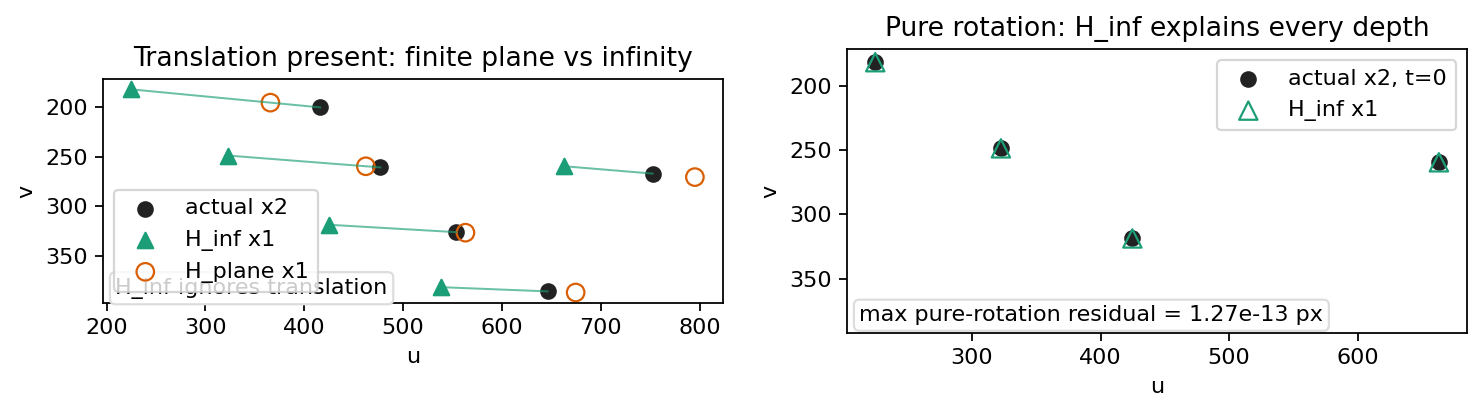

`artifacts/chapter-13/checks/plane-homography-invariants.json`

{'chapter': '13-scene-planes-and-homographies',
 'plane_model': 'n.T @ X + d = 0 in camera-1 coordinates',
 'libraries': ['numpy',
  'opencv cv2.perspectiveTransform',
  'opencv cv2.warpPerspective',
  'matplotlib',
  'sympy'],
 'max_planar_transfer_residual_px': 3.410605131648481e-13,
 'mean_planar_transfer_residual_px': 8.1120133877648e-14,
 'max_formula_vs_projection_px': 3.410605131648481e-13,
 'formula_vs_dlt_frobenius': 2.542202219915376e-13,
 'min_off_plane_parallax_px': 18.265551844628014,
 'mean_off_plane_parallax_px': 30.95180853629619,
 'max_epipolar_point_distance_px': 1.0532984834612129e-13,
 'max_transfer_point_epipolar_distance_px': 9.516325105917455e-14,
 'max_epipole_on_parallax_join_distance_px': 1.921588915150305e-11,
 'max_infinite_homography_translation_residual_px': 192.1231067854263,
 'max_finite_plane_depth_residual_px': 50.62890449792453,
 'max_pure_rotation_infinite_h_residual_px': 1.2710574864626038e-13,
 'pure_rotation_fundamental_norm': 0.0,
 'symbolic_limi

In [7]:
ray_xy = np.array([[-1.05, -0.55], [-0.55, -0.2], [-0.05, 0.15], [0.48, 0.45], [1.05, -0.15]], dtype=float)
depths = np.array([2.9, 3.6, 4.3, 5.1, 6.0])
depth_points = np.column_stack([ray_xy * depths[:, None] / plane_z, depths])
x1_depth = project(K, np.eye(3), np.zeros(3), depth_points)
x2_depth = project(K, R, t, depth_points)
x2_depth_inf = apply_H(H_inf, x1_depth)
x2_depth_plane = apply_H(H_plane, x1_depth)
inf_translation_residual = np.linalg.norm(x2_depth - x2_depth_inf, axis=1)
finite_plane_depth_residual = np.linalg.norm(x2_depth - x2_depth_plane, axis=1)

x2_pure_rotation = project(K, R, np.zeros(3), depth_points)
x2_pure_rotation_inf = apply_H(H_inf, x1_depth)
pure_rotation_residuals = np.linalg.norm(x2_pure_rotation - x2_pure_rotation_inf, axis=1)
pure_rotation_F = np.linalg.inv(K).T @ skew(np.zeros(3)) @ R @ np.linalg.inv(K)

lam = sp.symbols("lambda", positive=True)
r11, tau, nu = sp.symbols("r11 tau nu")
symbolic_limit_translation = sp.simplify(sp.limit(r11 - tau * nu / lam, lam, sp.oo))

fig, axes = plt.subplots(1, 2, figsize=(11, 5.2))
axes[0].set_title("Translation present: finite plane vs infinity")
axes[0].scatter(x2_depth[:, 0], x2_depth[:, 1], c="#222222", s=42, label="actual x2")
axes[0].scatter(x2_depth_inf[:, 0], x2_depth_inf[:, 1], marker="^", c="#1b9e77", s=48, label="H_inf x1")
axes[0].scatter(x2_depth_plane[:, 0], x2_depth_plane[:, 1], marker="o", facecolors="none", edgecolors="#d95f02", s=62, label="H_plane x1")
for actual, hinf in zip(x2_depth, x2_depth_inf):
    axes[0].plot([actual[0], hinf[0]], [actual[1], hinf[1]], color="#1b9e77", lw=0.9, alpha=0.65)
axes[0].invert_yaxis(); axes[0].set_aspect("equal", adjustable="box")
axes[0].set_xlabel("u"); axes[0].set_ylabel("v")
axes[0].legend(loc="best", frameon=True)
axes[0].text(0.02, 0.04, "H_inf ignores translation", transform=axes[0].transAxes, bbox={"boxstyle": "round,pad=0.25", "fc": "white", "ec": "#dddddd"})

axes[1].set_title("Pure rotation: H_inf explains every depth")
axes[1].scatter(x2_pure_rotation[:, 0], x2_pure_rotation[:, 1], c="#222222", s=42, label="actual x2, t=0")
axes[1].scatter(x2_pure_rotation_inf[:, 0], x2_pure_rotation_inf[:, 1], marker="^", facecolors="none", edgecolors="#1b9e77", s=68, label="H_inf x1")
for a, b in zip(x2_pure_rotation, x2_pure_rotation_inf):
    axes[1].plot([a[0], b[0]], [a[1], b[1]], color="#1b9e77", lw=0.9, alpha=0.7)
axes[1].invert_yaxis(); axes[1].set_aspect("equal", adjustable="box")
axes[1].set_xlabel("u"); axes[1].set_ylabel("v")
axes[1].legend(loc="best", frameon=True)
axes[1].text(0.02, 0.04, f"max pure-rotation residual = {pure_rotation_residuals.max():.2e} px", transform=axes[1].transAxes, bbox={"boxstyle": "round,pad=0.25", "fc": "white", "ec": "#dddddd"})

inf_path = save_matplotlib(fig, TOPIC, "figures", "infinite-homography-rotation.png")
plt.close(fig)
artifact_paths.append(inf_path)
display_artifact(inf_path)

invariants = {
    "chapter": "13-scene-planes-and-homographies",
    "plane_model": "n.T @ X + d = 0 in camera-1 coordinates",
    "libraries": ["numpy", "opencv cv2.perspectiveTransform", "opencv cv2.warpPerspective", "matplotlib", "sympy"],
    "max_planar_transfer_residual_px": float(plane_transfer_residuals.max()),
    "mean_planar_transfer_residual_px": float(plane_transfer_residuals.mean()),
    "max_formula_vs_projection_px": float(formula_vs_projection),
    "formula_vs_dlt_frobenius": float(formula_vs_dlt),
    "min_off_plane_parallax_px": float(parallax_lengths.min()),
    "mean_off_plane_parallax_px": float(parallax_lengths.mean()),
    "max_epipolar_point_distance_px": float(epipolar_point_distances.max()),
    "max_transfer_point_epipolar_distance_px": float(transfer_point_distances.max()),
    "max_epipole_on_parallax_join_distance_px": float(epipole_on_parallax_lines.max()),
    "max_infinite_homography_translation_residual_px": float(inf_translation_residual.max()),
    "max_finite_plane_depth_residual_px": float(finite_plane_depth_residual.max()),
    "max_pure_rotation_infinite_h_residual_px": float(pure_rotation_residuals.max()),
    "pure_rotation_fundamental_norm": float(np.linalg.norm(pure_rotation_F)),
    "symbolic_limit_entry_r_minus_tn_over_depth": str(symbolic_limit_translation),
    "artifacts": [str(p.relative_to(BOOK_ROOT)) for p in artifact_paths],
}
invariants_path = save_json(invariants, TOPIC, "checks", "plane-homography-invariants.json")
artifact_paths.append(invariants_path)
display_artifact(invariants_path)
invariants


## Plane-Induced `H` From `F` And Correspondences

The chapter also treats implicit construction: when `F` is known and enough image elements define a world plane, the homography can be found without first naming the plane in 3D coordinates. In this notebook the synthetic 3D plane is known, so the diagnostic role is reversed: a DLT homography from planar image correspondences should agree with the calibrated formula, and all pairs `x <-> Hx` must satisfy the same epipolar geometry. In real data, failure of this compatibility test is a sign that the chosen correspondences are not coplanar, are noisy enough to need optimization, or describe a degenerate configuration such as a plane through a camera center.


In [8]:
plane_epi_errors = sampson_errors(F, x1_plane, x2_plane_H)
actual_epi_errors = sampson_errors(F, x1_off, x2_off)
virtual_epi_errors = sampson_errors(F, x1_off, x2_off_by_plane)
compatibility_report = {
    "max_plane_pair_sampson_error": float(plane_epi_errors.max()),
    "max_actual_off_plane_sampson_error": float(actual_epi_errors.max()),
    "max_virtual_plane_transfer_sampson_error": float(virtual_epi_errors.max()),
    "rank_F": int(np.linalg.matrix_rank(F, tol=1e-9)),
    "rank_H_plane": int(np.linalg.matrix_rank(H_plane, tol=1e-9)),
    "rank_H_infinity": int(np.linalg.matrix_rank(H_inf, tol=1e-9)),
}
compatibility_report


{'max_plane_pair_sampson_error': 8.147211454860125e-27,
 'max_actual_off_plane_sampson_error': 5.374626648885718e-27,
 'max_virtual_plane_transfer_sampson_error': 4.541941979367417e-27,
 'rank_F': 2,
 'rank_H_plane': 3,
 'rank_H_infinity': 3}

## Pitfalls And Failure Modes

A plane homography is a two-view transfer rule, not a proof that every scene point lies on the plane. Applying `H_plane` to off-plane points gives a useful virtual point, but it should not be mistaken for the true correspondence. The gap is the parallax signal.

A homography estimated from arbitrary four-point matches may be a perfectly good 2D projective map while failing to be induced by any world plane compatible with the view pair. That is why the epipolar residuals are part of the checks.

The finite-plane formula is sensitive to the plane convention. Here `n.T @ X + d = 0` and `P2 = K [R | t]`; changing either convention changes the sign of the rank-one translation term. The notebook checks the formula against direct projection to catch exactly that sign error.

The infinite homography is not a substitute for a finite plane when translation is present. It transfers directions and pure-rotation images; finite-depth points still carry translation-dependent parallax.


## Applied Lab

Replace the synthetic grid with measured points from a planar calibration target, a building facade, or a tabletop scene. Estimate a homography from at least four planar correspondences, then compare it with additional points known to be on the same plane. Use off-plane points to draw parallax vectors and confirm that their joins meet at the epipole or at least align with the corresponding epipolar lines. Finally, repeat the experiment with a pure pan/tilt camera motion: the measured image transfer should approach the infinite homography and become independent of scene depth.


In [9]:
final_sanity = {
    "artifact_count": len(artifact_paths),
    "all_artifacts": [str(path.relative_to(BOOK_ROOT)) for path in artifact_paths],
    "max_planar_transfer_residual_px": float(plane_transfer_residuals.max()),
    "max_formula_vs_projection_px": float(formula_vs_projection),
    "min_off_plane_parallax_px": float(parallax_lengths.min()),
    "max_epipolar_point_distance_px": float(epipolar_point_distances.max()),
    "max_epipole_on_parallax_join_distance_px": float(epipole_on_parallax_lines.max()),
    "max_pure_rotation_infinite_h_residual_px": float(pure_rotation_residuals.max()),
    "pure_rotation_fundamental_norm": float(np.linalg.norm(pure_rotation_F)),
}

assert_artifacts([transfer_path, parallax_path, factor_path, inf_path], min_bytes=1500)
assert transfer_path.exists() and transfer_path.stat().st_size > 1500
assert parallax_path.exists() and parallax_path.stat().st_size > 1500
assert factor_path.exists() and factor_path.stat().st_size > 1500
assert inf_path.exists() and inf_path.stat().st_size > 1500
assert invariants_path.exists() and invariants_path.stat().st_size > 500
assert final_sanity["artifact_count"] == 5
assert final_sanity["max_planar_transfer_residual_px"] < 1e-8
assert final_sanity["max_formula_vs_projection_px"] < 1e-8
assert final_sanity["min_off_plane_parallax_px"] > 2.0
assert final_sanity["max_epipolar_point_distance_px"] < 1e-8
assert final_sanity["max_epipole_on_parallax_join_distance_px"] < 1e-7
assert final_sanity["max_pure_rotation_infinite_h_residual_px"] < 1e-8
assert final_sanity["pure_rotation_fundamental_norm"] == 0.0
assert symbolic_limit_translation == r11
final_sanity


{'artifact_count': 5,
 'all_artifacts': ['artifacts\\chapter-13\\figures\\plane-induced-transfer-field.png',
  'artifacts\\chapter-13\\figures\\off-plane-parallax-vectors.png',
  'artifacts\\chapter-13\\figures\\plane-homography-factorization.png',
  'artifacts\\chapter-13\\figures\\infinite-homography-rotation.png',
  'artifacts\\chapter-13\\checks\\plane-homography-invariants.json'],
 'max_planar_transfer_residual_px': 3.410605131648481e-13,
 'max_formula_vs_projection_px': 3.410605131648481e-13,
 'min_off_plane_parallax_px': 18.265551844628014,
 'max_epipolar_point_distance_px': 1.0532984834612129e-13,
 'max_epipole_on_parallax_join_distance_px': 1.921588915150305e-11,
 'max_pure_rotation_infinite_h_residual_px': 1.2710574864626038e-13,
 'pure_rotation_fundamental_norm': 0.0}

## Takeaways

- A nondegenerate world plane induces a full-rank image homography between two views.
- The calibrated formula `K (R - t n.T / d) K^-1` exposes the roles of rotation, translation, plane normal, and plane depth.
- A plane homography and the fundamental matrix are compatible: even the virtual transfer `Hx` lies on the same epipolar line as the real correspondence.
- Off-plane parallax is not an error to hide; it is the signal that lets a known plane help recover epipolar geometry or classify relative depth.
- The infinite homography is the rotation component `K R K^-1`; for pure rotation it transfers all depths, while with translation it describes directions rather than finite scene points.
